# CE497 · Learning a transient fluid simulation
## MeshGraphNets-style GNN versus U-Net
**Case study:** pressure-driven startup flow between two stationary parallel plates.  
**For:** Yue (Olivia) Meng · Purdue University · CE497 AI in Civil Engineering  
**Course repository:** https://github.com/olivmeng/CE497_AI-Civil

Compare **an independent triangular-mesh FEM simulation**, **a graph neural network**, **a grid-based U-Net**, and **analytical solutions**. Both networks learn a time-step operator and then generate complete trajectories using their own previous predictions.

### Run this notebook
Open this `.ipynb` in **Google Colab → File → Upload notebook**, then choose **Runtime → Run all**. A CPU is sufficient for the default demonstration; a GPU is optional. To run the full learning exercise, change `TRAIN_FROM_SCRATCH = True` below and rerun all cells.

**Scope matters.** This is a **2D mesh/grid representation of fully developed, unidirectional channel flow**. Its velocity varies across the channel and in time, but not along the channel. This symmetry reduces Navier–Stokes to a diffusion equation with constant forcing. It is not an entrance-flow, cylinder-wake, free-surface, turbulence, or general 2D pressure–velocity solver. We learn the axial velocity $u$; $v=0$ is prescribed by the physical ansatz, not predicted.

### Learning goals and experimental design
Explain the difference between a graph and a structured-grid representation; assemble a small P1 finite-element model; distinguish a one-step prediction from an autoregressive rollout; validate against both transient and steady analytical solutions; and measure accuracy, drift, parameter count, and runtime without assuming neural models are faster.

| Item | Numerical reference | Mesh GNN | U-Net |
|:--|:--|:--|:--|
| Representation | 2D P1 triangular mesh | Nodes and directed triangle edges | Same nodes reshaped to a 2D array |
| Evolution | Mass-lumped FEM, implicit Euler substeps | Learned residual time step | Learned residual time step |
| Boundary conditions | Periodic in $x$, no-slip walls in $y$ | Periodic graph edges; wall projection | Periodic convolution padding in $x$; wall projection |
| Inputs | State, viscosity, forcing | State, $y/H$, wall type, viscosity, forcing; edge geometry | Same state and five node-feature channels |
| During rollout | Sparse solves | No FEM calls or true future states | No FEM calls or true future states |

**U-Net is a CNN.** Its encoder downsamples feature maps, its decoder upsamples them, and skip connections retain fine-scale information [2]. Our compact regression model outputs a velocity increment rather than segmentation classes.

The GNN follows the **encode–process–decode and residual-update ideas** in MeshGraphNets [1]. It uses fewer latent channels and message-passing blocks, mean aggregation, SiLU activations, and short multistep training. It does not reproduce the paper's architecture, adaptive remeshing, or published benchmarks. The official release documents datasets and training code, but no compatible Poiseuille checkpoint was found [3]. The embedded weights were trained specifically for this notebook; they are **not DeepMind pretrained weights**.

In [1]:
# Install only missing packages; do not replace Colab's existing PyTorch/CUDA stack.
import importlib.util
import subprocess
import sys

required = {"numpy": "numpy", "scipy": "scipy", "matplotlib": "matplotlib",
            "pandas": "pandas", "torch": "torch"}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import os, math, time, copy, json, random, io, base64, zlib, hashlib, platform
from pathlib import Path
import numpy as np
import pandas as pd
import scipy
import scipy.sparse as sp
import scipy.sparse.linalg as sla
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.animation import FuncAnimation
import torch
from torch import nn
import torch.nn.functional as F
from IPython.display import display, HTML, Markdown

print("Python:", platform.python_version())
print("NumPy:", np.__version__, "SciPy:", scipy.__version__, "PyTorch:", torch.__version__)

Python: 3.13.15
NumPy: 2.1.3 SciPy: 1.16.3 PyTorch: 2.11.0+cpu


In [2]:
# ---- Student controls ----
TRAIN_FROM_SCRATCH = True
TRAIN_ITERATIONS = 2400
BATCH_SIZE = 8
MAKE_ANIMATION = True
RUN_OOD_TEST = True
SEED = 497

# Embedded checkpoints require these mesh and time-step settings.
NX, NY, LX = 16, 17, 4.0
DT, STEPS = 0.04, 30

# Physical reference scales: assumed water-like properties, SI units.
H_REF = 0.010           # Full channel height [m]
U_REF = 0.010           # Velocity scale [m/s]
NU_REF = 1.0e-6         # Kinematic-viscosity scale [m^2/s]
RHO = 1000.0           # Assumed density [kg/m^3]
T_REF = H_REF**2 / NU_REF
A_REF = U_REF * NU_REF / H_REF**2
L_PHYSICAL = LX * H_REF

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(min(2, os.cpu_count() or 1))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RESULTS_DIR = Path("poiseuille_results")
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES = []
def save_figure(name):
    path = RESULTS_DIR / (name + ".png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    FIGURES.append(str(path))
    plt.show()
    plt.close()

print("Device:", DEVICE)
print(f"Channel: {L_PHYSICAL*1000:g} mm long × {H_REF*1000:g} mm high")
print(f"Saved time step: {DT*T_REF:g} s; final time: {STEPS*DT*T_REF:g} s")
print("Changes to mesh, time step, architecture, or training distribution require retraining.")

Device: cpu
Channel: 40 mm long × 10 mm high
Saved time step: 4 s; final time: 120 s
Changes to mesh, time step, architecture, or training distribution require retraining.


## 1 · Physics and analytical solutions
Let $0\le y\le H$ and let the velocity be $\mathbf{u}=(u(y,t),0)$. A constant pressure gradient is switched on at $t=0$:
$$
 a=-\frac{1}{\rho}\frac{\partial p}{\partial x}>0,\qquad
 \frac{\partial u}{\partial t}=\nu\frac{\partial^2u}{\partial y^2}+a,
 \quad u(0,t)=u(H,t)=0.
$$
For startup from rest, $u(y,0)=0$. The nonlinear advection term vanishes because $\partial_xu=0$ and $v=0$; incompressibility is then satisfied exactly. On the two-dimensional FEM domain we assemble $\partial_tu=\nu\nabla^2u+a$ with periodic axial velocity. The imposed mean pressure gradient is represented as a body acceleration; **the total pressure itself is not periodic**.

With $y^*=y/H$, $x^*=x/H$, $u^*=u/U_{\mathrm{ref}}$, $t^*=t\nu_{\mathrm{ref}}/H^2$, $\nu^*=\nu/\nu_{\mathrm{ref}}$, and $f^*=aH^2/(U_{\mathrm{ref}}\nu_{\mathrm{ref}})$:
$$
 \partial_{t^*}u^*=\nu^*\nabla^{*2}u^*+f^*.
$$
Code uses these dimensionless variables; figures convert back to SI or millimetres.

### Steady limit
Integrating $\nu u''+a=0$ and applying the wall conditions gives
$$
 \boxed{u_\infty(y)=\frac{a}{2\nu}y(H-y)},\qquad
 U_{\max}=\frac{aH^2}{8\nu},\qquad
 \overline{U}=\frac{aH^2}{12\nu},\qquad
 Q'=\frac{aH^3}{12\nu}.
$$
$Q'$ is volumetric flow per unit span, with units $\mathrm{m^2/s}$.

### Transient startup
Subtracting the steady solution and expanding in wall-compatible sine modes gives
$$
 u(y,t)=\frac{a}{2\nu}y(H-y)
 -\frac{4aH^2}{\nu\pi^3}
 \sum_{n=1,3,5,\ldots}\frac{\sin(n\pi y/H)}{n^3}
 \exp\!\left[-\nu(n\pi/H)^2t\right].
$$
The code truncates this convergent series at 150 odd modes and sets $t=0$ exactly to zero. The analytical solution is an **independent validation target**, not the neural rollout update. The slowest relaxation time is $H^2/(\pi^2\nu)$.

## 2 · Build a genuine triangular FEM mesh
The rectangular grid is split into triangles. Left/right nodes are identified periodically during assembly; wall nodes remain explicit. There are **272 independent nodes and 512 triangles** at the default resolution. The GNN receives all directed triangle edges, including the diagonal edges and the periodic connections. The U-Net receives exactly the same nodal values, with **no interpolation advantage or penalty**.

For linear triangle basis functions $N_i$, assemble
$$
 K_{ij}=\int_\Omega\nabla N_i\cdot\nabla N_j\,d\Omega,
 \qquad (M_L)_{ii}=\sum_{T\ni i}\frac{|T|}{3}.
$$
Here $M_L$ is the lumped mass matrix. The ground-truth integrator advances interior nodes with eight backward-Euler substeps per saved frame:
$$
 (M_L+\delta t\,\nu^*K)u^{n+1}
   =M_Lu^n+\delta t\,f^*M_L\mathbf{1}.
$$
The sparse matrix factorization is reused. This is a small, explicit NumPy/SciPy FEM implementation—not a neural approximation and not a call to the analytical formula [4].

In [3]:
def make_mesh(nx=NX, ny=NY, lx=LX):
    """P1 triangles on a rectangle. Identify the two x-boundaries periodically."""
    x = np.linspace(0, lx, nx + 1)
    y = np.linspace(0, 1, ny)
    X, Y = np.meshgrid(x, y)
    points = np.stack([X.ravel(), Y.ravel()], 1)
    tri = []
    for j in range(ny - 1):
        for i in range(nx):
            a = j * (nx + 1) + i
            b = a + 1
            c = a + nx + 1
            d = c + 1
            tri.extend([[a, b, d], [a, d, c]])
    tri = np.asarray(tri, dtype=np.int64)
    dof_map = np.array([j * nx + i % nx for j in range(ny) for i in range(nx + 1)])
    coords = np.array([[x[i], y[j]] for j in range(ny) for i in range(nx)])
    n = nx * ny
    rows = []
    cols = []
    vals = []
    mass = np.zeros(n)
    for t in tri:
        p = points[t]
        a, b, c = p
        area = abs(np.linalg.det(np.array([b - a, c - a]))) / 2
        B = np.array([[b[1] - c[1], c[1] - a[1], a[1] - b[1]], [c[0] - b[0], a[0] - c[0], b[0] - a[0]]]) / (2 * area)
        Ke = area * B.T @ B
        ids = dof_map[t]
        for r in range(3):
            mass[ids[r]] += area / 3
            for s in range(3):
                rows.append(ids[r])
                cols.append(ids[s])
                vals.append(Ke[r, s])
    K = sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsc()
    edges = set()
    for t in dof_map[tri]:
        for a, b in ((t[0], t[1]), (t[1], t[2]), (t[2], t[0])):
            if a != b:
                edges.add((int(a), int(b)))
                edges.add((int(b), int(a)))
    edges = np.array(sorted(edges), dtype=np.int64).T
    delta = coords[edges[0]] - coords[edges[1]]
    delta[:, 0] = (delta[:, 0] + lx / 2) % lx - lx / 2
    edge_attr = np.column_stack([delta, np.linalg.norm(delta, axis=1)])
    edge_attr /= 1 / (ny - 1)
    interior = np.where((coords[:, 1] > 0) & (coords[:, 1] < 1))[0]
    return dict(nx=nx, ny=ny, lx=lx, points=points, tri=tri, map=dof_map, coords=coords, edges=edges, edge_attr=edge_attr, K=K, mass=mass, interior=interior)

MESH = make_mesh()

272 independent nodes; 512 triangles; 1568 directed graph edges


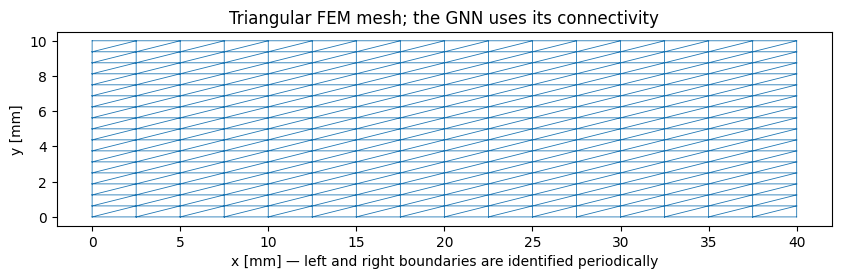

In [4]:
# Assembly and boundary-condition checks.
assert np.isclose(MESH["mass"].sum(), LX)
assert np.max(np.abs((MESH["K"] - MESH["K"].T).data), initial=0) < 1e-10
assert np.linalg.norm(MESH["K"] @ np.ones(NX*NY)) < 1e-10
assert len(MESH["interior"]) == NX*(NY-2)
edge_set = set(map(tuple, MESH["edges"].T))
assert all((j, i) in edge_set for i, j in edge_set)
print(f"{NX*NY} independent nodes; {len(MESH['tri'])} triangles; "
      f"{MESH['edges'].shape[1]} directed graph edges")

plt.figure(figsize=(10, 3.6))
plt.triplot(MESH["points"][:, 0]*H_REF*1000,
            MESH["points"][:, 1]*H_REF*1000, MESH["tri"], linewidth=0.6)
plt.xlabel("x [mm] — left and right boundaries are identified periodically")
plt.ylabel("y [mm]")
plt.title("Triangular FEM mesh; the GNN uses its connectivity")
plt.gca().set_aspect("equal")
save_figure("01_fem_mesh")

In [5]:
def fem_rollout(nu, forcing, u0=None, steps=STEPS, dt=DT, mesh=MESH, substeps=8):
    """Independent 2D mass-lumped P1 FEM + implicit Euler substeps."""
    ii = mesh['interior']
    m = mesh['mass'][ii]
    K = mesh['K'][ii][:, ii]
    h = dt / substeps
    solve = sla.splu(sp.diags(m, format='csc') + h * nu * K).solve
    u = np.zeros(len(mesh['mass'])) if u0 is None else np.asarray(u0, dtype=float).copy()
    u[np.setdiff1d(np.arange(u.size), ii)] = 0
    out = [u.copy()]
    for _ in range(steps):
        for _ in range(substeps):
            u[ii] = solve(m * (u[ii] + h * forcing))
        out.append(u.copy())
    return np.array(out)

def steady_profile(y, nu, forcing):
    return forcing / (2 * nu) * y * (1 - y)

def exact_startup(y, t, nu, forcing, nterms=150):
    y = np.asarray(y)
    t = np.atleast_1d(t)
    n = np.arange(1, 2 * nterms, 2)
    series = np.einsum('tm,m,my->ty', np.exp(-nu * np.pi ** 2 * t[:, None] * n[None, :] ** 2), 4 * forcing / (nu * np.pi ** 3 * n ** 3), np.sin(np.pi * n[:, None] * y[None, :]))
    out = steady_profile(y, nu, forcing)[None, :] - series
    out[t == 0] = 0
    out[:, np.isclose(y, 0) | np.isclose(y, 1)] = 0
    return out

FEM vs transient analytical series, full-trajectory relative L2: 0.4233%


,NY,substeps/frame,trajectory L2 error [%]
0,17,4,0.78724
1,17,8,0.42334
2,33,16,0.20083
3,65,32,0.09768


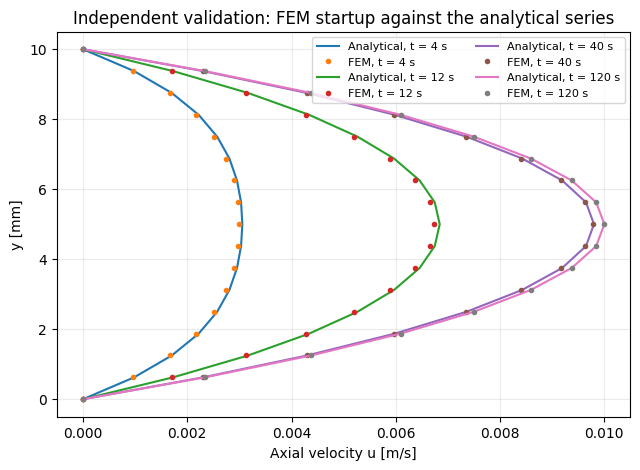

In [6]:
# Validate the numerical solver before generating training data.
check_nu, check_f = 1.0, 8.0
check_times = np.arange(STEPS+1)*DT
y_nodes = np.linspace(0, 1, NY)
check_gt = fem_rollout(check_nu, check_f)
check_exact = exact_startup(y_nodes, check_times, check_nu, check_f)
check_profile = check_gt.reshape(-1, NY, NX).mean(axis=-1)
solver_error = np.linalg.norm(check_profile[1:] - check_exact[1:]) / np.linalg.norm(check_exact[1:])
wall_ids = np.r_[np.arange(NX), np.arange((NY-1)*NX, NY*NX)]
assert np.max(np.abs(check_gt[:, wall_ids])) < 1e-12
assert np.max(np.ptp(check_gt.reshape(-1, NY, NX), axis=-1)) < 1e-10
assert solver_error < 0.02, "Ground-truth error unexpectedly large: inspect the discretization."
print(f"FEM vs transient analytical series, full-trajectory relative L2: {100*solver_error:.4f}%")

# Refinement changes both wall-normal spacing and internal time step.
convergence_rows = []
for ny_refined, nsub in [(17, 4), (17, 8), (33, 16), (65, 32)]:
    refined = make_mesh(NX, ny_refined, LX)
    ref_gt = fem_rollout(1.0, 8.0, mesh=refined, substeps=nsub)
    ref_a = exact_startup(np.linspace(0, 1, ny_refined), check_times, 1.0, 8.0)
    ref_p = ref_gt.reshape(-1, ny_refined, NX).mean(axis=-1)
    err = np.linalg.norm(ref_p[1:]-ref_a[1:])/np.linalg.norm(ref_a[1:])
    convergence_rows.append({"NY": ny_refined, "substeps/frame": nsub,
                             "trajectory L2 error [%]": 100*err})
convergence = pd.DataFrame(convergence_rows)
display(convergence.round(5))
convergence.to_csv(RESULTS_DIR/"fem_convergence.csv", index=False)

plt.figure(figsize=(7.4, 5))
for index in [1, 3, 10, STEPS]:
    line, = plt.plot(check_exact[index]*U_REF, y_nodes*H_REF*1000,
                     label=f"Analytical, t = {check_times[index]*T_REF:g} s")
    plt.plot(check_profile[index]*U_REF, y_nodes*H_REF*1000,
             linestyle="none", marker="o", markersize=3,
             label=f"FEM, t = {check_times[index]*T_REF:g} s")
plt.xlabel("Axial velocity u [m/s]")
plt.ylabel("y [mm]")
plt.title("Independent validation: FEM startup against the analytical series")
plt.legend(fontsize=8, ncol=2)
plt.grid(alpha=0.25)
save_figure("02_fem_analytical_validation")

## 3 · Generate training and validation trajectories
Use **64 training trajectories** and **8 validation trajectories** generated with different random seeds. Parameters span $\nu^*\in[0.7,1.3]$ and $f^*\in[4,12]$. One third of the trajectories start from rest; the others start from smooth, axial-invariant sine-mode profiles. These extra initial conditions prevent the networks from merely fitting elapsed time along one startup curve. **Time is not an input.**

Each split contains complete trajectories. We never randomly split adjacent time snapshots into training and testing sets. All targets come from FEM. Neither an analytical velocity profile nor a true future frame is supplied during neural rollout. The prescribed forcing and viscosity remain known inputs, just as they are in the numerical simulation.

In [7]:
def create_dataset(n, seed, train=True):
    rng = np.random.default_rng(seed)
    params = []
    states = []
    y = MESH['coords'][:, 1]
    for k in range(n):
        nu = rng.uniform(0.7, 1.3)
        f = rng.uniform(4, 12)
        u0 = np.zeros_like(y)
        if k % 3 != 0:
            u0 = rng.uniform(0, 1.8) * np.sin(np.pi * y)
            for mode in range(1, 5):
                u0 += rng.uniform(-0.12, 0.12) / mode ** 2 * np.sin(mode * np.pi * y)
        states.append(fem_rollout(nu, f, u0).astype('float32'))
        params.append([nu, f / 8])
    return (np.array(states), np.array(params, dtype='float32'))

train_states, train_parameters = create_dataset(64, SEED)
val_states, val_parameters = create_dataset(8, SEED+1)
assert train_states.shape == (64, STEPS+1, NX*NY)
print("Training:", train_states.shape, "Validation:", val_states.shape)
print("Parameter columns: [dimensionless viscosity, dimensionless forcing / 8]")
display(pd.DataFrame(train_parameters[:6], columns=["nu*", "f*/8"]))

Training: (64, 31, 272) Validation: (8, 31, 272)
Parameter columns: [dimensionless viscosity, dimensionless forcing / 8]


,nu*,f*/8
0,0.978456,1.127503
1,1.174462,1.032626
2,1.191447,0.564738
3,1.283248,0.561226
4,0.900719,1.303682
5,0.991831,0.826616


## 4 · MeshGraphNets-style graph neural network

We use a **MeshGraphNets-style graph neural network (GNN)** to learn the transient evolution of velocity on the FEM mesh. Each FEM node becomes a graph node with five features:

$$
x_i =
[u_i^*,\; y_i/H,\; m_i,\; \nu^*,\; f^*/8].
$$

Here, $u_i^*$ is the current dimensionless velocity, $y_i/H$ is the normalized wall-normal position, $m_i$ is an interior-node mask, $\nu^*$ is the dimensionless viscosity, and $f^*$ is the dimensionless pressure-gradient forcing. The forcing is divided by 8 only for normalization.

Each mesh connection becomes a **directed graph edge**, with features describing the relative displacement and distance between connected nodes. Node and edge MLP encoders are followed by three residual message-passing blocks and an MLP decoder. The GNN predicts the velocity rate of change, and one time step is

$$
\hat{u}^{\,n+1}
=
\mathrm{BC}
\left[
\hat{u}^{\,n}
+
\Delta t\,
F_\theta
\left(
\hat{u}^{\,n},
\nu^*,
f^*,
G
\right)
\right].
$$

Here, $G$ represents the mesh graph, $F_\theta$ is the learned GNN, and $\mathrm{BC}$ sets the velocity to zero at the upper and lower channel walls. Thus, the network learns the time-step mapping

$$
(u^n,\nu^*,f^*) \rightarrow u^{n+1}.
$$

During an autonomous rollout, each prediction becomes the input to the next step:

$$
\hat{u}^0 \rightarrow \hat{u}^1 \rightarrow \hat{u}^2 \rightarrow \cdots
$$

The FEM solver and analytical solution are **not used during GNN rollout**. The network is trained for a fixed $\Delta t$. Incoming graph messages are summed using PyTorch's `index_add`, so PyTorch Geometric is not required.

In [8]:
class MLP(nn.Module):

    def __init__(self, ni, no, width, layer_norm=False):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(ni, width), nn.SiLU(), nn.Linear(width, no), *([nn.LayerNorm(no)] if layer_norm else []))

    def forward(self, x):
        return self.net(x)

class MeshGNN(nn.Module):

    def __init__(self, mesh=MESH, width=24, depth=3):
        super().__init__()
        self.nx = mesh['nx']
        self.ny = mesh['ny']
        self.n = len(mesh['mass'])
        self.register_buffer('src', torch.tensor(mesh['edges'][0]))
        self.register_buffer('dst', torch.tensor(mesh['edges'][1]))
        self.register_buffer('edge_attr', torch.tensor(mesh['edge_attr'], dtype=torch.float32))
        y = torch.tensor(mesh['coords'][:, 1], dtype=torch.float32)
        self.register_buffer('y', y)
        self.register_buffer('mask', ((y > 0) & (y < 1)).float())
        deg = torch.bincount(self.dst, minlength=self.n).float().clamp(min=1)
        self.register_buffer('degree', deg[None, :, None])
        self.node_encoder = MLP(5, width, width, True)
        self.edge_encoder = MLP(3, width, width, True)
        self.edge_blocks = nn.ModuleList([MLP(3 * width, width, width, True) for _ in range(depth)])
        self.node_blocks = nn.ModuleList([MLP(2 * width, width, width, True) for _ in range(depth)])
        self.decoder = MLP(width, 1, width)
        nn.init.zeros_(self.decoder.net[2].weight)
        nn.init.zeros_(self.decoder.net[2].bias)

    def forward(self, u, p):
        batch = u.shape[0]
        u = u.reshape(batch, -1)
        feat = torch.stack([u, self.y.expand_as(u), self.mask.expand_as(u), p[:, 0, None].expand_as(u), p[:, 1, None].expand_as(u)], -1)
        h = self.node_encoder(feat)
        e = self.edge_encoder(self.edge_attr).expand(batch, -1, -1)
        for eb, nb in zip(self.edge_blocks, self.node_blocks):
            e = e + eb(torch.cat([e, h[:, self.src], h[:, self.dst]], -1))
            agg = h.new_zeros(h.shape).index_add(1, self.dst, e) / self.degree
            h = h + nb(torch.cat([h, agg], -1))
        du = self.decoder(h).squeeze(-1)
        return (u + DT * du) * self.mask

## 5 · Compact U-Net CNN
The same five node features become five image channels. Two downsampling stages give a wider receptive field; two upsampling stages combine coarse features with encoder skip connections. Periodic padding is used in the axial direction. Output shape is restored explicitly, so the odd number of wall-normal nodes is supported. Both networks use the same residual update and exact wall projection.

This comparison uses a structured mesh deliberately: it isolates representation and architecture without introducing interpolation error. It does **not** demonstrate the GNN's potential advantage on irregular or adaptively refined meshes. Parameter counts are similar but not identical, and equal optimizer steps are not equal computational cost.

In [9]:
class ChannelConv(nn.Module):

    def __init__(self, cin, cout):
        super().__init__()
        self.conv = nn.Conv2d(cin, cout, 3, padding=0)

    def forward(self, x):
        x = F.pad(x, (1, 1, 0, 0), mode='circular')
        x = F.pad(x, (0, 0, 1, 1), mode='constant', value=0)
        return self.conv(x)

class ConvBlock(nn.Module):

    def __init__(self, ni, no):
        super().__init__()
        self.net = nn.Sequential(ChannelConv(ni, no), nn.SiLU(), ChannelConv(no, no), nn.SiLU())

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):

    def __init__(self, mesh=MESH, width=6):
        super().__init__()
        self.nx = mesh['nx']
        self.ny = mesh['ny']
        y = torch.tensor(mesh['coords'][:, 1], dtype=torch.float32).reshape(1, 1, self.ny, self.nx)
        self.register_buffer('y', y)
        self.register_buffer('mask', ((y > 0) & (y < 1)).float())
        self.e1 = ConvBlock(5, width)
        self.e2 = ConvBlock(width, 2 * width)
        self.mid = ConvBlock(2 * width, 4 * width)
        self.d2 = ConvBlock(6 * width, 2 * width)
        self.d1 = ConvBlock(3 * width, width)
        self.head = nn.Conv2d(width, 1, 1)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, u, p):
        batch = u.shape[0]
        z = u.reshape(batch, 1, self.ny, self.nx)
        q = torch.cat([z, self.y.expand_as(z), self.mask.expand_as(z), p[:, 0, None, None, None].expand_as(z), p[:, 1, None, None, None].expand_as(z)], 1)
        a = self.e1(q)
        b = self.e2(F.avg_pool2d(a, 2))
        c = self.mid(F.avg_pool2d(b, 2))
        d = self.d2(torch.cat([F.interpolate(c, size=b.shape[-2:], mode='nearest'), b], 1))
        e = self.d1(torch.cat([F.interpolate(d, size=a.shape[-2:], mode='nearest'), a], 1))
        return ((z + DT * self.head(e)) * self.mask).reshape(batch, -1)

## 6 · Training, validation, and checkpoint provenance
Both models see identical sampled trajectories, time indices, smooth input noise, targets, batch size, and optimizer-update budgets. Training begins with one-step supervision and switches to three-step unrolled supervision halfway through. Small sine-mode noise is added to the input; the target remains the clean future state. This trains the model to recover from small state errors.

The loss is an area-weighted squared velocity error, divided by $\Delta t^2$ for scaling, averaged over the supervised steps. AdamW and a cosine learning-rate schedule are used. The saved model is selected by the **lowest complete-rollout error on validation trajectories**, not by test performance. Neither model is tuned or selected using the test-case results below.

Default mode loads checkpoints actually trained for 2,400 optimizer updates per model on the numerical dataset above. Recorded training histories and timings are embedded with the weights. Set `TRAIN_FROM_SCRATCH=True` to replace them with a new run. Reproducibility is seeded, but GPU kernels and library changes can still change the numerical result.

In [10]:
@torch.no_grad()
def nn_rollout(model, p, u0=None, steps=STEPS):
    model.eval()
    p = torch.as_tensor(p, dtype=torch.float32, device=DEVICE)
    if p.ndim == 1:
        p = p[None]
    u = torch.zeros((len(p), NX * NY), device=DEVICE) if u0 is None else torch.as_tensor(u0, dtype=torch.float32, device=DEVICE).reshape(len(p), -1)
    out = [u.cpu().numpy()]
    for i in range(steps):
        u = model(u, p)
        out.append(u.cpu().numpy())
        if not torch.isfinite(u).all():
            break
    return np.stack(out, axis=1)

def train_model(model, train, params, val, valp, iterations=1000, batch_size=8, seed=SEED):
    model.to(DEVICE)
    rng = np.random.default_rng(seed)
    data = torch.as_tensor(train, device=DEVICE)
    pp = torch.as_tensor(params, device=DEVICE)
    weights = torch.tensor(MESH['mass'], dtype=torch.float32, device=DEVICE)
    weights /= weights.sum()
    opt = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-06)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, iterations, eta_min=0.0001)
    best = math.inf
    best_state = None
    history = []
    start = time.perf_counter()
    for it in range(iterations):
        model.train()
        horizon = 1 if it < iterations // 2 else 3
        ids = rng.integers(len(train), size=batch_size)
        ts = rng.integers(0, STEPS - horizon + 1, size=batch_size)
        if it % 3 == 0:
            ts = rng.integers(0, min(8, STEPS - horizon + 1), size=batch_size)
        u = data[ids, ts]
        p = pp[ids]
        loss = 0
        noise_amp = 0.002
        y = torch.tensor(MESH['coords'][:, 1], dtype=torch.float32, device=DEVICE)
        amps = torch.tensor(rng.normal(0, noise_amp, (batch_size, 3)), dtype=torch.float32, device=DEVICE)
        basis = torch.sin(torch.arange(1, 4, device=DEVICE)[:, None] * torch.pi * y[None, :])
        u = u + amps @ basis
        for k in range(horizon):
            u = model(u, p)
            diff = (u - data[ids, ts + k + 1]) / DT
            loss = loss + (diff.square() * weights).sum(-1).mean() / horizon
        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()
        if (it + 1) % 100 == 0 or it == 0:
            pred = nn_rollout(model, valp, val[:, 0])
            err = np.linalg.norm(pred[:, 1:] - val[:, 1:]) / np.linalg.norm(val[:, 1:])
            history.append([it + 1, float(loss.detach()), float(err)])
            if np.isfinite(err) and err < best:
                best = err
                best_state = copy.deepcopy(model.state_dict())
            print(type(model).__name__, it + 1, 'loss', round(float(loss.detach()), 5), 'val_rollout', round(float(err), 5), 'sec', round(time.perf_counter() - start, 1), flush=True)
    model.load_state_dict(best_state)
    return (history, time.perf_counter() - start)

In [11]:
#@title Embedded demonstration checkpoints and provenance (expand to inspect)
CHECKPOINT_PROVENANCE = {'gnn': {'iterations': 2400, 'batch_size': 8, 'seed': 497, 'train_trajectories': 64, 'validation_trajectories': 8, 'elapsed_seconds': 137.56348925600003, 'device': 'cpu', 'torch': '2.10.0+cpu', 'parameters': 14833, 'sha256': '46061fa3471cb48a6fdee9129a00998e12d278bfc18f5d150b0fa3a6fdca6706', 'history': [[1.0, 3.5065484046936035, 0.9191908240318298], [100.0, 3.2896060943603516, 0.6189836859703064], [200.0, 0.3455696403980255, 0.46916744112968445], [300.0, 0.10367996245622635, 0.2760299742221832], [400.0, 0.2536489963531494, 0.12763826549053192], [500.0, 0.07494163513183594, 0.10729123651981354], [600.0, 0.028159361332654953, 0.07292651385068893], [700.0, 0.04786622151732445, 0.05225659906864166], [800.0, 0.021410251036286354, 0.06791844964027405], [900.0, 0.014599389396607876, 0.038267314434051514], [1000.0, 0.09678105264902115, 0.05070175230503082], [1100.0, 0.024483509361743927, 0.03871345520019531], [1200.0, 0.028361709788441658, 0.042419422417879105], [1300.0, 0.10951553285121918, 0.030395427718758583], [1400.0, 0.025854554027318954, 0.021702218800783157], [1500.0, 0.024125516414642334, 0.016740089282393456], [1600.0, 0.006323892157524824, 0.016178349032998085], [1700.0, 0.009443424642086029, 0.0149910356849432], [1800.0, 0.018955091014504433, 0.013406735844910145], [1900.0, 0.043409280478954315, 0.011843370273709297], [2000.0, 0.004776781424880028, 0.010355919599533081], [2100.0, 0.004739990923553705, 0.009129070676863194], [2200.0, 0.013845983892679214, 0.009478620253503323], [2300.0, 0.010884354822337627, 0.010319202207028866], [2400.0, 0.01556888222694397, 0.00909937359392643]]}, 'unet': {'iterations': 2400, 'batch_size': 8, 'seed': 497, 'train_trajectories': 64, 'validation_trajectories': 8, 'elapsed_seconds': 34.80361381299997, 'device': 'cpu', 'torch': '2.10.0+cpu', 'parameters': 16921, 'sha256': '8726ff7a3704668cdf44787be79112ebbd16bd216f12b0df005f72cfbd910745', 'history': [[1.0, 3.5065484046936035, 0.925284206867218], [100.0, 1.2389789819717407, 0.21920053660869598], [200.0, 0.08709575235843658, 0.16737788915634155], [300.0, 0.02600981295108795, 0.1123775988817215], [400.0, 0.22661767899990082, 0.1444433182477951], [500.0, 0.4413224160671234, 0.2222631275653839], [600.0, 0.04791117087006569, 0.14659658074378967], [700.0, 0.10375174134969711, 0.12749071419239044], [800.0, 0.016662415117025375, 0.09856197237968445], [900.0, 0.08062124252319336, 0.23285071551799774], [1000.0, 0.18405303359031677, 0.1317337155342102], [1100.0, 0.5417523980140686, 0.09140736609697342], [1200.0, 0.06650526076555252, 0.07481664419174194], [1300.0, 0.22614921629428864, 0.07050296664237976], [1400.0, 0.06359820067882538, 0.0853142961859703], [1500.0, 0.10671252012252808, 0.05555945634841919], [1600.0, 0.055355317890644073, 0.04964623972773552], [1700.0, 0.053599681705236435, 0.047845080494880676], [1800.0, 0.04438348114490509, 0.05012347921729088], [1900.0, 0.14987075328826904, 0.041141968220472336], [2000.0, 0.019459791481494904, 0.043242502957582474], [2100.0, 0.0481438934803009, 0.04278215393424034], [2200.0, 0.14896485209465027, 0.041845474392175674], [2300.0, 0.083152174949646, 0.036361075937747955], [2400.0, 0.07780981063842773, 0.03801244497299194]]}, 'configuration': {'NX': 16, 'NY': 17, 'LX': 4.0, 'DT': 0.04, 'STEPS': 30, 'fem_substeps': 8, 'gnn_width': 24, 'gnn_depth': 3, 'unet_width': 6, 'seed': 497, 'dataset_version': 'sine_initial_conditions_v1'}}
EMBEDDED_WEIGHTS = {'gnn': '...', 'unet': '...'}

MeshGNN 1 loss 3.50655 val_rollout 0.91919 sec 1.5
MeshGNN 100 loss 3.2896 val_rollout 0.61898 sec 9.5
MeshGNN 200 loss 0.34557 val_rollout 0.46917 sec 21.7
MeshGNN 300 loss 0.10366 val_rollout 0.27603 sec 32.4
MeshGNN 400 loss 0.38451 val_rollout 0.10494 sec 42.8
MeshGNN 500 loss 0.05419 val_rollout 0.06127 sec 50.8
MeshGNN 600 loss 0.0169 val_rollout 0.05662 sec 61.2
MeshGNN 700 loss 0.03166 val_rollout 0.04672 sec 71.5
MeshGNN 800 loss 0.11246 val_rollout 0.11947 sec 79.4
MeshGNN 900 loss 0.07935 val_rollout 0.06265 sec 91.8
MeshGNN 1000 loss 0.14627 val_rollout 0.04917 sec 113.0
MeshGNN 1100 loss 0.03022 val_rollout 0.03808 sec 122.4
MeshGNN 1200 loss 0.02329 val_rollout 0.04571 sec 131.3
MeshGNN 1300 loss 0.06208 val_rollout 0.02638 sec 157.8
MeshGNN 1400 loss 0.03332 val_rollout 0.02469 sec 184.4
MeshGNN 1500 loss 0.03635 val_rollout 0.01507 sec 210.9
MeshGNN 1600 loss 0.0163 val_rollout 0.01694 sec 237.3
MeshGNN 1700 loss 0.00886 val_rollout 0.01262 sec 263.8
MeshGNN 1800 loss 0

,Model,Trainable parameters,Training updates,Recorded training seconds,Training device
0,GNN,14833,2400,453.14,cpu
1,U-Net,16921,2400,110.13,cpu


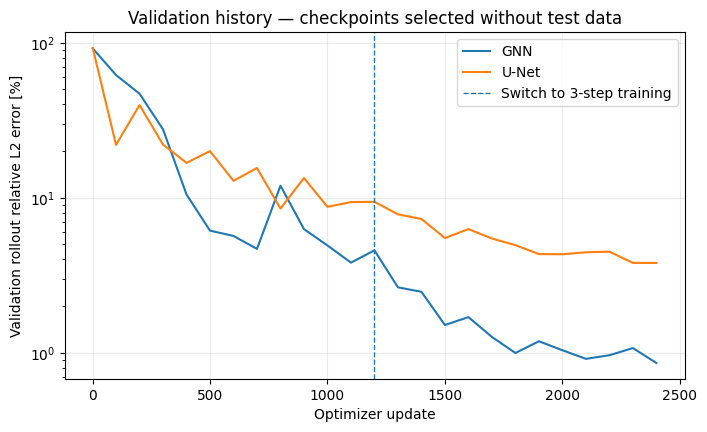

In [12]:
models, histories, training_records = {}, {}, {}
for name, cls in [("gnn", MeshGNN), ("unet", UNet)]:
    torch.manual_seed(SEED)
    model = cls().to(DEVICE)
    if TRAIN_FROM_SCRATCH:
        history, elapsed = train_model(
            model, train_states, train_parameters, val_states, val_parameters,
            iterations=TRAIN_ITERATIONS, batch_size=BATCH_SIZE, seed=SEED)
        histories[name] = history
        training_records[name] = {"source": "trained in this run",
                                  "elapsed_seconds": elapsed,
                                  "device": str(DEVICE), "iterations": TRAIN_ITERATIONS}
    else:
        expected = CHECKPOINT_PROVENANCE["configuration"]
        actual = dict(NX=NX, NY=NY, LX=LX, DT=DT, STEPS=STEPS)
        if any(actual[key] != expected[key] for key in actual):
            raise ValueError("Embedded weights do not match these settings. "
                             "Restore the defaults or enable TRAIN_FROM_SCRATCH.")
        raw = zlib.decompress(base64.b64decode(EMBEDDED_WEIGHTS[name]))
        if hashlib.sha256(raw).hexdigest() != CHECKPOINT_PROVENANCE[name]["sha256"]:
            raise ValueError("Checkpoint checksum mismatch.")
        state = torch.load(io.BytesIO(raw), map_location=DEVICE, weights_only=True)
        model.load_state_dict(state, strict=True)
        histories[name] = CHECKPOINT_PROVENANCE[name]["history"]
        training_records[name] = {**CHECKPOINT_PROVENANCE[name],
                                  "source": "embedded locally trained demonstration checkpoint"}
    model.eval()
    models[name] = model
    torch.save(model.state_dict(), RESULTS_DIR/(name+"_weights.pt"))

capacity_rows = []
for name, model in models.items():
    capacity_rows.append({"Model": name.upper() if name == "gnn" else "U-Net",
                         "Trainable parameters": sum(p.numel() for p in model.parameters()),
                         "Training updates": training_records[name]["iterations"],
                         "Recorded training seconds": training_records[name]["elapsed_seconds"],
                         "Training device": training_records[name]["device"]})
capacity = pd.DataFrame(capacity_rows)
display(capacity.round(2))
capacity.to_csv(RESULTS_DIR/"model_capacity_and_training.csv", index=False)

plt.figure(figsize=(8, 4.5))
for name, history in histories.items():
    history = np.asarray(history)
    plt.semilogy(history[:, 0], 100*history[:, 2], label=name.upper() if name=="gnn" else "U-Net")
plt.axvline((TRAIN_ITERATIONS if TRAIN_FROM_SCRATCH else 2400)/2,
            linestyle="--", linewidth=1, label="Switch to 3-step training")
plt.xlabel("Optimizer update")
plt.ylabel("Validation rollout relative L2 error [%]")
plt.title("Validation history — checkpoints selected without test data")
plt.legend()
plt.grid(alpha=0.25)
save_figure("03_validation_history")

## 7 · Held-out startup cases: one-step accuracy versus rollout accuracy
The following six pressure-gradient/viscosity combinations are fixed test cases, all starting from rest. None is used for training or checkpoint selection. They lie within the parameter ranges used for training; this is **parameter interpolation**, not evidence of geometric generalization.

For an area-weighted norm $\|z\|_M^2=\sum_i m_i z_i^2$, the rollout error is
$$
 E_\mathrm{roll}=\sqrt{\frac{\sum_{n=1}^{N}\|\widehat u^n-u_\mathrm{FEM}^n\|_M^2}
 {\sum_{n=1}^{N}\|u_\mathrm{FEM}^n\|_M^2}}.
$$
**One-step** predictions receive the true previous state. **Rollouts** receive only the initial condition and their own previous predictions. The zero initial frame is excluded from relative-error denominators. A persistence baseline makes the distinction especially clear: it predicts no change and stays at rest in an autonomous startup rollout.

In [13]:
TEST_CASES = [(0.80, 5.5), (0.90, 10.5), (1.00, 8.0),
              (1.10, 6.5), (1.20, 11.0), (1.25, 8.5)]
MAIN_CASE = 2
mass_weights = MESH["mass"]/MESH["mass"].sum()

def relative_l2(prediction, reference):
    numerator = np.sum((np.asarray(prediction)-reference)**2*mass_weights)
    denominator = np.sum(np.asarray(reference)**2*mass_weights)
    return float(np.sqrt(numerator/max(denominator, 1e-20)))

def weighted_rmse(prediction, reference):
    squared = (np.asarray(prediction)-reference)**2*mass_weights
    return float(np.sqrt(np.mean(np.sum(squared, axis=-1))))

@torch.no_grad()
def teacher_forced(model, truth, parameter):
    u = torch.tensor(truth[:-1], dtype=torch.float32, device=DEVICE)
    p = torch.tensor(parameter, dtype=torch.float32, device=DEVICE).expand(len(u), -1)
    return model(u, p).cpu().numpy()

all_cases, metric_rows = [], []
for case_id, (nu, forcing) in enumerate(TEST_CASES):
    truth = fem_rollout(nu, forcing)
    predictions = {name: nn_rollout(model, [nu, forcing/8])[0]
                   for name, model in models.items()}
    all_cases.append({"nu": nu, "forcing": forcing, "truth": truth, **predictions})
    for name, model in models.items():
        prediction = predictions[name]
        assert prediction.shape == truth.shape and np.isfinite(prediction).all()
        assert np.max(np.abs(prediction[:, wall_ids])) < 1e-8
        next_frame = teacher_forced(model, truth, [nu, forcing/8])
        analytical_steady = steady_profile(MESH["coords"][:,1], nu, forcing)
        metric_rows.append({"Case": case_id, "nu*": nu, "f*": forcing,
                            "Model": "GNN" if name=="gnn" else "U-Net",
                            "One-step L2 [%]": 100*relative_l2(next_frame, truth[1:]),
                            "Rollout L2 [%]": 100*relative_l2(prediction[1:], truth[1:]),
                            "Rollout RMSE [m/s]": U_REF*weighted_rmse(prediction[1:], truth[1:]),
                            "Late-time vs analytical steady [%]": 100*relative_l2(prediction[-1], analytical_steady)})

metrics = pd.DataFrame(metric_rows)
display(metrics.round(5))
metrics.to_csv(RESULTS_DIR/"test_case_metrics.csv", index=False)
summary = metrics.groupby("Model")[["One-step L2 [%]", "Rollout L2 [%]",
                                    "Late-time vs analytical steady [%]"]].agg(["mean", "max"])
display(summary.round(4))
summary.to_csv(RESULTS_DIR/"test_summary.csv")

case = all_cases[MAIN_CASE]
nu, forcing, truth = case["nu"], case["forcing"], case["truth"]
predictions = {name: case[name] for name in models}
times = np.arange(STEPS+1)*DT
analytical = exact_startup(y_nodes, times, nu, forcing)
analytical_steady = steady_profile(y_nodes, nu, forcing)
profiles = {"FEM": truth.reshape(-1, NY, NX).mean(-1),
            "GNN": predictions["gnn"].reshape(-1, NY, NX).mean(-1),
            "U-Net": predictions["unet"].reshape(-1, NY, NX).mean(-1)}
physical_nu, physical_a = nu*NU_REF, forcing*A_REF
u_max = forcing/(8*nu)*U_REF
u_mean = 2*u_max/3
print(f"Main case: nu = {physical_nu:.3g} m²/s, a = {physical_a:.3g} m/s², "
      f"dp/dx = {-RHO*physical_a:.3g} Pa/m")
print(f"Analytical Umax = {u_max:.6f} m/s; mean velocity = {u_mean:.6f} m/s")
print(f"Reynolds number based on mean velocity and hydraulic diameter 2H: {u_mean*2*H_REF/physical_nu:.2f}")
print(f"Persistence: teacher-forced L2 = {100*relative_l2(truth[:-1],truth[1:]):.3f}%; "
      "autonomous rollout L2 = 100%")

,Case,nu*,f*,Model,One-step L2 [%],Rollout L2 [%],Rollout RMSE [m/s],Late-time vs analytical steady [%]
0,0,0.80,5.5,GNN,0.37973,0.74502,0.00004,0.54367
1,0,0.80,5.5,U-Net,1.64041,4.02331,0.00023,2.25564
2,1,0.90,10.5,GNN,0.29699,0.75145,0.00007,0.65711
3,1,0.90,10.5,U-Net,0.47314,1.43342,0.00014,1.87524
4,2,1.00,8.0,GNN,0.38780,0.71069,0.00005,0.62602
5,2,1.00,8.0,U-Net,0.56195,1.57469,0.00011,1.21410
6,3,1.10,6.5,GNN,0.30069,0.67156,0.00003,0.65383
7,3,1.10,6.5,U-Net,0.46681,1.78323,0.00009,1.84049
8,4,1.20,11.0,GNN,0.25862,0.56385,0.00004,0.55258
9,4,1.20,11.0,U-Net,0.50518,2.03383,0.00016,2.80053


One-step L2 [%]         Rollout L2 [%]          \
                 mean     max           mean     max   
Model                                                  
GNN            0.3256  0.3878         0.6928  0.7514   
U-Net          0.7373  1.6404         2.1766  4.0233   

      Late-time vs analytical steady [%]          
                                    mean     max  
Model                                             
GNN                               0.6211  0.6934  
U-Net                             1.8930  2.8005

Main case: nu = 1e-06 m²/s, a = 0.0008 m/s², dp/dx = -0.8 Pa/m
Analytical Umax = 0.010000 m/s; mean velocity = 0.006667 m/s
Reynolds number based on mean velocity and hydraulic diameter 2H: 133.33
Persistence: teacher-forced L2 = 8.469%; autonomous rollout L2 = 100%


## 8 · Compare two-dimensional fields and velocity profiles
The field view displays a **transient frame**, not just the final parabola. A single shared scale is used for all three methods. Cross-sections below are averaged over the periodic axial direction; the benchmark is axially invariant, so this average should not conceal meaningful physical structure. The diagnostics later also report axial variation.

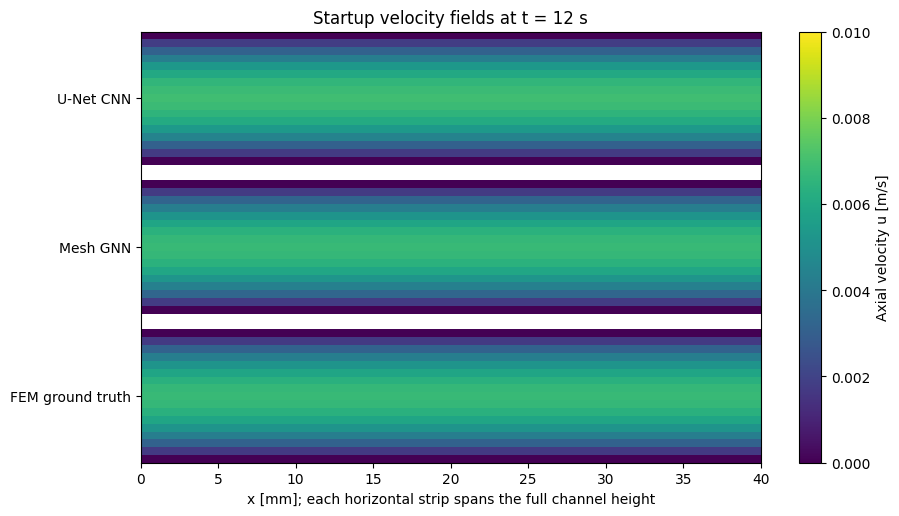

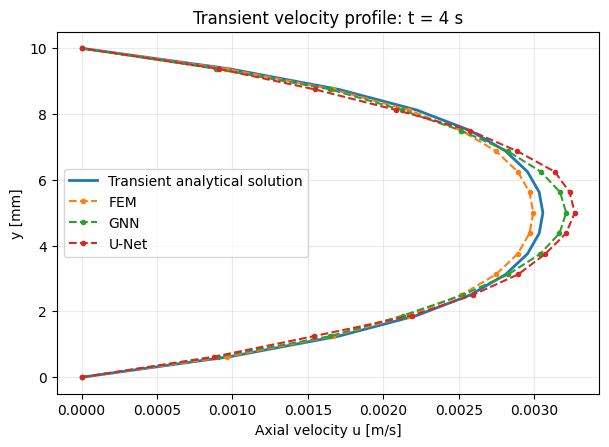

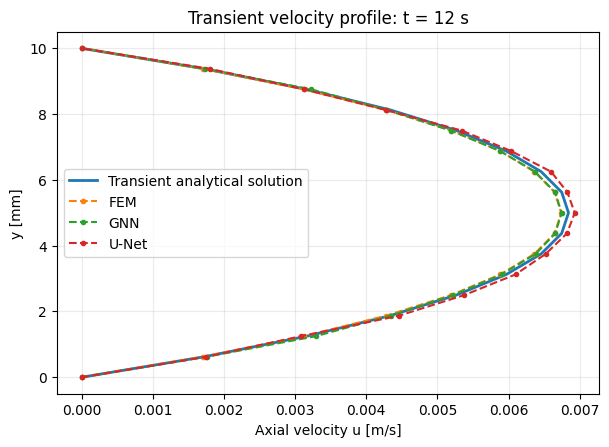

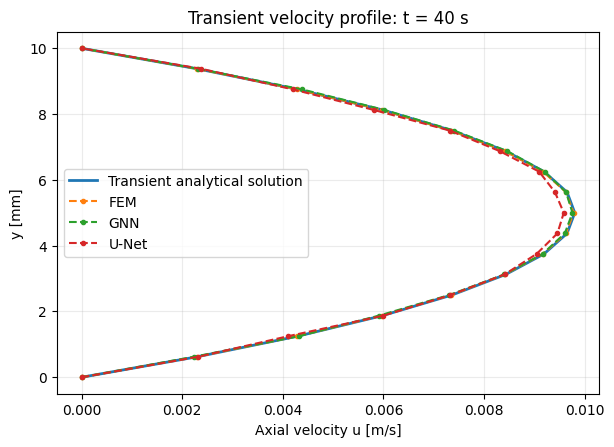

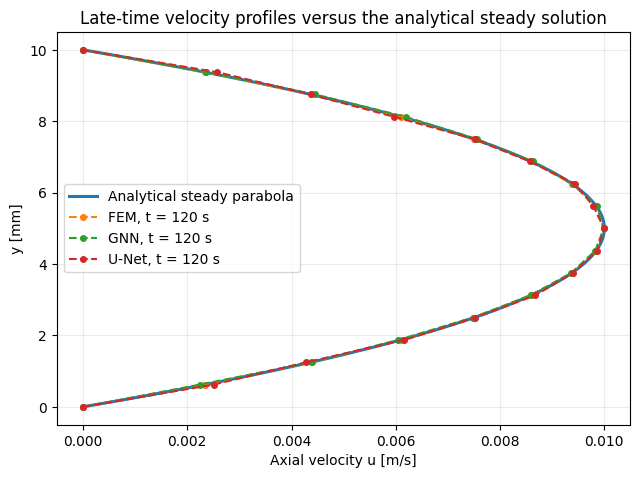

Late-time neural profiles are not automatically steady states. Check drift and residuals below.


In [14]:
# Stack the three fields in one axes with blank separators and one shared color scale.
SNAPSHOT = 3

def stacked_field(frame):
    gap = np.full((2, NX), np.nan)
    return np.vstack([truth[frame].reshape(NY, NX), gap,
                      predictions["gnn"][frame].reshape(NY, NX), gap,
                      predictions["unet"][frame].reshape(NY, NX)])

plt.figure(figsize=(10, 5.6))
image = plt.imshow(stacked_field(SNAPSHOT)*U_REF, origin="lower", aspect="auto",
                   extent=[0, L_PHYSICAL*1000, 0, 3*NY+4],
                   vmin=0, vmax=u_max)
plt.yticks([NY/2, NY+2+NY/2, 2*(NY+2)+NY/2],
           ["FEM ground truth", "Mesh GNN", "U-Net CNN"])
plt.xlabel("x [mm]; each horizontal strip spans the full channel height")
plt.title(f"Startup velocity fields at t = {times[SNAPSHOT]*T_REF:g} s")
plt.colorbar(image, label="Axial velocity u [m/s]")
save_figure("04_transient_velocity_fields")

# Individual transient cross-sections: all methods overlaid in each figure.
for index in [1, 3, 10]:
    plt.figure(figsize=(7, 4.7))
    plt.plot(analytical[index]*U_REF, y_nodes*H_REF*1000,
             linewidth=2, label="Transient analytical solution")
    for label, values in profiles.items():
        plt.plot(values[index]*U_REF, y_nodes*H_REF*1000,
                 marker="o", markersize=3, linestyle="--", label=label)
    plt.xlabel("Axial velocity u [m/s]")
    plt.ylabel("y [mm]")
    plt.title(f"Transient velocity profile: t = {times[index]*T_REF:g} s")
    plt.legend()
    plt.grid(alpha=0.25)
    save_figure(f"05_transient_profile_step_{index:02d}")

# Requested steady-profile comparison; do not assume the NN has reached equilibrium.
plt.figure(figsize=(7.4, 5.1))
y_fine = np.linspace(0, 1, 301)
plt.plot(steady_profile(y_fine, nu, forcing)*U_REF, y_fine*H_REF*1000,
         linewidth=2.2, label="Analytical steady parabola")
for label, values in profiles.items():
    plt.plot(values[-1]*U_REF, y_nodes*H_REF*1000,
             marker="o", markersize=4, linestyle="--", label=f"{label}, t = {times[-1]*T_REF:g} s")
plt.xlabel("Axial velocity u [m/s]")
plt.ylabel("y [mm]")
plt.title("Late-time velocity profiles versus the analytical steady solution")
plt.legend()
plt.grid(alpha=0.25)
save_figure("06_steady_velocity_profile")
print("Late-time neural profiles are not automatically steady states. Check drift and residuals below.")

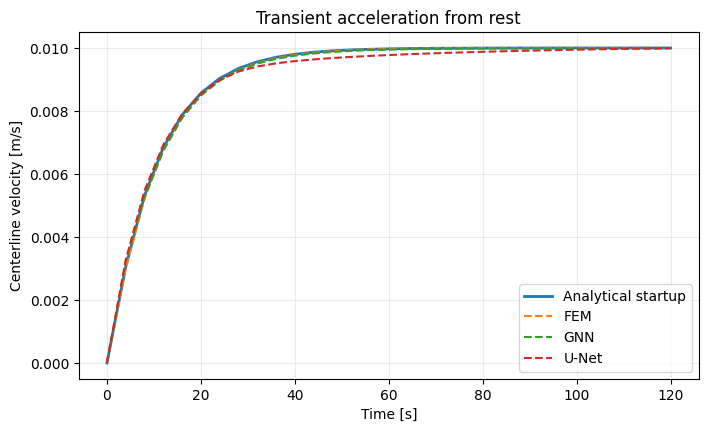

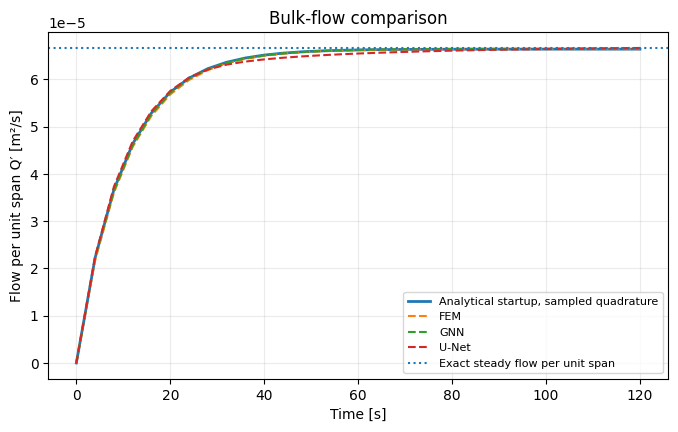

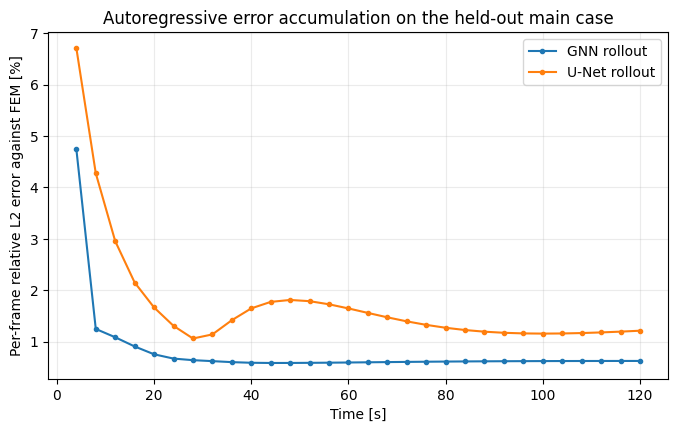

In [15]:
# Centerline startup history.
plt.figure(figsize=(8, 4.5))
plt.plot(times*T_REF, analytical[:, NY//2]*U_REF,
         linewidth=2, label="Analytical startup")
for label, values in profiles.items():
    plt.plot(times*T_REF, values[:, NY//2]*U_REF, linestyle="--", label=label)
plt.xlabel("Time [s]")
plt.ylabel("Centerline velocity [m/s]")
plt.title("Transient acceleration from rest")
plt.legend()
plt.grid(alpha=0.25)
save_figure("07_centerline_history")

# Flow per unit span, using the same quadrature on each profile.
q_exact = trapezoid(analytical, y_nodes, axis=1)*U_REF*H_REF
plt.figure(figsize=(8, 4.5))
plt.plot(times*T_REF, q_exact, linewidth=2, label="Analytical startup, sampled quadrature")
for label, values in profiles.items():
    q = trapezoid(values, y_nodes, axis=1)*U_REF*H_REF
    plt.plot(times*T_REF, q, linestyle="--", label=label)
plt.axhline(forcing/(12*nu)*U_REF*H_REF, linestyle=":", label="Exact steady flow per unit span")
plt.xlabel("Time [s]")
plt.ylabel("Flow per unit span Q′ [m²/s]")
plt.title("Bulk-flow comparison")
plt.legend(fontsize=8)
plt.grid(alpha=0.25)
save_figure("08_flow_rate_history")

# Error accumulation, excluding the zero initial frame.
plt.figure(figsize=(8, 4.5))
for name, prediction in predictions.items():
    errors = [100*relative_l2(p, g) for p, g in zip(prediction[1:], truth[1:])]
    plt.plot(times[1:]*T_REF, errors, marker="o", markersize=3,
             label="GNN rollout" if name=="gnn" else "U-Net rollout")
plt.xlabel("Time [s]")
plt.ylabel("Per-frame relative L2 error against FEM [%]")
plt.title("Autoregressive error accumulation on the held-out main case")
plt.legend()
plt.grid(alpha=0.25)
save_figure("09_rollout_error")

## 9 · Is the late-time neural prediction actually steady?
A visually parabolic velocity field is not sufficient. We check the last-step change, the discrete steady PDE residual, axial variation, and a rollout extending five times beyond the training horizon. These are **diagnostics**, not penalties used to force agreement after prediction.

The relative residual is the weighted RMS of $\nu^*K\widehat u/M_L-f^*$ on interior nodes, divided by $|f^*|$. It can be appreciable even when velocity error looks small, because spatial differentiation amplifies small profile errors. Since $v=0$ is prescribed, axial variation would also indicate a violation of the fully developed, divergence-free ansatz.

,Model,Late-time vs steady L2 [%],Last-step change / steady norm [%],Steady PDE residual / forcing [%],Max axial spread [m/s]
0,FEM,0.000988,0.000463,0.000916,0.0
1,GNN,0.626024,0.003224,24.683713,0.0
2,U-Net,1.214100,0.062729,75.525259,0.0


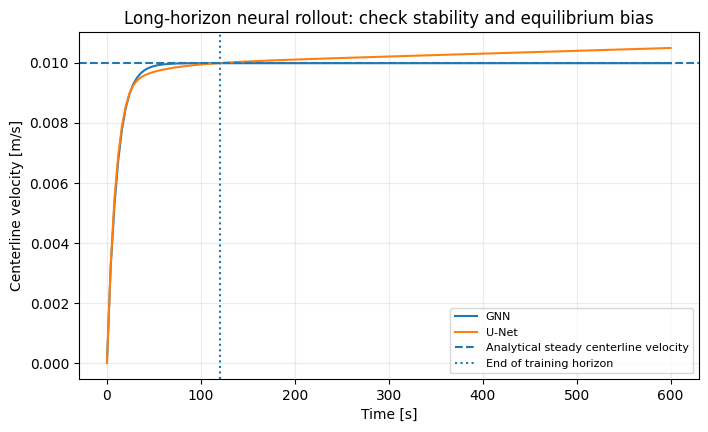

gnn long-horizon final relative error vs analytical steady: 0.6256%
unet long-horizon final relative error vs analytical steady: 4.9366%


In [16]:
diagnostic_rows = []
steady_nodes = steady_profile(MESH["coords"][:, 1], nu, forcing)
ii = MESH["interior"]
iweights = MESH["mass"][ii]/MESH["mass"][ii].sum()
for label, states in [("FEM", truth), ("GNN", predictions["gnn"]), ("U-Net", predictions["unet"])]:
    u = states[-1]
    residual = nu*(MESH["K"]@u)[ii]/MESH["mass"][ii] - forcing
    increment = np.sqrt(np.sum((states[-1]-states[-2])**2*mass_weights))
    steady_norm = np.sqrt(np.sum(steady_nodes**2*mass_weights))
    diagnostic_rows.append({"Model": label,
        "Late-time vs steady L2 [%]": 100*relative_l2(u, steady_nodes),
        "Last-step change / steady norm [%]": 100*increment/steady_norm,
        "Steady PDE residual / forcing [%]": 100*np.sqrt(np.sum(residual**2*iweights))/abs(forcing),
        "Max axial spread [m/s]": U_REF*np.max(np.ptp(u.reshape(NY,NX),axis=1))})
diagnostics = pd.DataFrame(diagnostic_rows)
display(diagnostics.round(6))
diagnostics.to_csv(RESULTS_DIR/"steady_state_diagnostics.csv", index=False)

LONG_STEPS = 5*STEPS
long_times = np.arange(LONG_STEPS+1)*DT
long_predictions = {name: nn_rollout(model, [nu, forcing/8], steps=LONG_STEPS)[0]
                    for name, model in models.items()}
plt.figure(figsize=(8, 4.5))
for name, states in long_predictions.items():
    center = states.reshape(-1,NY,NX)[:,NY//2].mean(-1)*U_REF
    plt.plot(long_times[:len(center)]*T_REF, center, label="GNN" if name=="gnn" else "U-Net")
plt.axhline(u_max, linestyle="--", label="Analytical steady centerline velocity")
plt.axvline(STEPS*DT*T_REF, linestyle=":", label="End of training horizon")
plt.xlabel("Time [s]")
plt.ylabel("Centerline velocity [m/s]")
plt.title("Long-horizon neural rollout: check stability and equilibrium bias")
plt.legend(fontsize=8)
plt.grid(alpha=0.25)
save_figure("10_long_horizon_drift")
for name, states in long_predictions.items():
    print(name, "long-horizon final relative error vs analytical steady:",
          f"{100*relative_l2(states[-1],steady_nodes):.4f}%")

## 10 · Optional parameter extrapolation
This stress test changes both viscosity and pressure forcing beyond their training intervals. It uses the same mesh and macro time step. Error here is not folded into the interpolation score above; a successful in-range example does not establish reliable extrapolation.

In [17]:
if RUN_OOD_TEST:
    ood_nu, ood_f = 0.50, 14.0
    ood_truth = fem_rollout(ood_nu, ood_f)
    ood_rows = []
    for name, model in models.items():
        out = nn_rollout(model, [ood_nu, ood_f/8])[0]
        finite = len(out) == len(ood_truth) and np.isfinite(out).all()
        error = 100*relative_l2(out[1:], ood_truth[1:]) if finite else float("inf")
        ood_rows.append({"Model": name, "nu*": ood_nu, "f*": ood_f,
                         "Rollout L2 [%]": error, "Finite rollout": finite})
    ood_metrics = pd.DataFrame(ood_rows)
    display(ood_metrics.round(4))
    ood_metrics.to_csv(RESULTS_DIR/"out_of_distribution_metrics.csv", index=False)
else:
    print("Out-of-distribution stress test skipped.")

,Model,nu*,f*,Rollout L2 [%],Finite rollout
0,gnn,0.5,14.0,14.2272,True
1,unet,0.5,14.0,14.4580,True


## 11 · Timing without assuming a neural speedup
Compare one saved FEM frame (eight reused-factorization substeps) with one neural macro-step. Warm up both methods; synchronize CUDA before and after timing. Neural timing uses resident tensors and excludes host/device transfers; FEM runs on CPU. When a GPU is selected, this is therefore a **cross-device practical comparison**, not an equal-hardware algorithmic benchmark. Setup, training, plotting, and data generation are reported or discussed separately.

At this tiny mesh size the sparse FEM solver may be faster than either neural model. It would be misleading to extrapolate a speedup from a larger simulation in the paper to this small teaching problem.

In [18]:
def synchronize():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

@torch.no_grad()
def time_neural_step(model, repeats=100):
    u = torch.tensor(truth[3:4], dtype=torch.float32, device=DEVICE)
    p = torch.tensor([[nu, forcing/8]], dtype=torch.float32, device=DEVICE)
    for _ in range(10):
        model(u, p)
    synchronize()
    start = time.perf_counter()
    for _ in range(repeats):
        model(u, p)
    synchronize()
    return 1000*(time.perf_counter()-start)/repeats

nsub = 8
h = DT/nsub
m = MESH["mass"][ii]
setup_start = time.perf_counter()
fem_solve = sla.splu(sp.diags(m,format="csc") + h*nu*MESH["K"][ii][:,ii]).solve
fem_setup_ms = 1000*(time.perf_counter()-setup_start)
fem_initial = truth[3,ii].copy()
def fem_one_frame():
    u = fem_initial.copy()
    for _ in range(nsub):
        u = fem_solve(m*(u+h*forcing))
    return u
for _ in range(10):
    fem_one_frame()
start = time.perf_counter()
for _ in range(100):
    fem_one_frame()
fem_ms = 1000*(time.perf_counter()-start)/100
speed_rows = [{"Method": "FEM (8 substeps)", "Device": "cpu",
               "ms / saved frame": fem_ms, "FEM time / method time": 1.0}]
for name, model in models.items():
    elapsed_ms = time_neural_step(model)
    speed_rows.append({"Method": "GNN" if name=="gnn" else "U-Net",
                        "Device": str(DEVICE), "ms / saved frame": elapsed_ms,
                        "FEM time / method time": fem_ms/elapsed_ms})
speeds = pd.DataFrame(speed_rows)
display(speeds.round(4))
print(f"FEM sparse-factorization setup, excluded from step timing: {fem_setup_ms:.3f} ms")
print("A speed ratio below 1 means the neural step is slower than the reused-factorization FEM step.")
speeds.to_csv(RESULTS_DIR/"inference_timing.csv", index=False)

,Method,Device,ms / saved frame,FEM time / method time
0,FEM (8 substeps),cpu,0.2711,1.0000
1,GNN,cpu,4.5480,0.0596
2,U-Net,cpu,1.5539,0.1744


FEM sparse-factorization setup, excluded from step timing: 1.916 ms
A speed ratio below 1 means the neural step is slower than the reused-factorization FEM step.


## 12 · Animated transient comparison
Use the animation controls to compare development of the velocity field. All methods share a single velocity scale. The animation contains actual stored model rollouts, not synthetic illustrative fields.

In [19]:
if MAKE_ANIMATION:
    fig = plt.figure(figsize=(10, 5.5))
    ax = plt.gca()
    image = ax.imshow(stacked_field(0)*U_REF, origin="lower", aspect="auto",
                      extent=[0, L_PHYSICAL*1000, 0, 3*NY+4], vmin=0, vmax=u_max)
    ax.set_yticks([NY/2, NY+2+NY/2, 2*(NY+2)+NY/2],
                  ["FEM ground truth", "Mesh GNN", "U-Net CNN"])
    ax.set_xlabel("x [mm]; each strip spans the full channel height")
    title = ax.set_title("Startup from rest: t = 0 s")
    fig.colorbar(image, label="Axial velocity u [m/s]")
    def update_animation(frame):
        image.set_data(stacked_field(frame)*U_REF)
        title.set_text(f"Startup from rest: t = {times[frame]*T_REF:g} s")
        return image, title
    animation = FuncAnimation(fig, update_animation, frames=STEPS+1,
                               interval=150, blit=False)
    animation_html = animation.to_jshtml()
    plt.close(fig)
    (RESULTS_DIR/"startup_animation.html").write_text(animation_html)
    display(HTML(animation_html))
else:
    print("Animation skipped; static figures remain available.")

## 13 · Export the reproducible results
This cell saves metrics, parameter splits, numerical and neural trajectories, checkpoints, training histories, run metadata, and every static figure. The resulting zip can be retrieved from Colab's Files pane. Changing physical reference scales only rescales this nondimensional benchmark; it does not establish validity in a new physical flow regime.

In [20]:
import shutil

np.savez_compressed(RESULTS_DIR/"main_case_trajectories.npz",
    times_dimensionless=times, times_seconds=times*T_REF,
    mesh_coordinates_dimensionless=MESH["coords"],
    truth_dimensionless=truth, gnn_dimensionless=predictions["gnn"],
    unet_dimensionless=predictions["unet"],
    analytical_profiles_dimensionless=analytical,
    analytical_steady_dimensionless=analytical_steady,
    nu_dimensionless=nu, forcing_dimensionless=forcing,
    velocity_scale_m_per_s=U_REF, length_scale_m=H_REF)
np.savez_compressed(RESULTS_DIR/"training_and_validation_data.npz",
    train_states=train_states, train_parameters=train_parameters,
    validation_states=val_states, validation_parameters=val_parameters)
for name, history in histories.items():
    pd.DataFrame(history, columns=["update", "training_loss", "validation_rollout_relative_l2"]).to_csv(
        RESULTS_DIR/(name+"_training_history.csv"), index=False)
run_metadata = {
    "python": platform.python_version(), "numpy": np.__version__, "scipy": scipy.__version__,
    "torch": torch.__version__, "inference_device": str(DEVICE),
    "training_mode": "from scratch" if TRAIN_FROM_SCRATCH else "embedded demonstration weights",
    "NX": NX, "NY": NY, "LX": LX, "DT": DT, "STEPS": STEPS,
    "fem_substeps": 8, "seed": SEED, "test_cases": TEST_CASES,
    "H_m": H_REF, "Uref_m_per_s": U_REF, "nuref_m2_per_s": NU_REF,
    "training_records": training_records,
    "scope": "Fully developed unidirectional channel flow on a 2D mesh; v=0 prescribed",
}
(RESULTS_DIR/"run_metadata.json").write_text(json.dumps(run_metadata, indent=2))
archive = shutil.make_archive(str(RESULTS_DIR), "zip", root_dir=RESULTS_DIR)
print("Saved:", archive)
print("In Colab, use the Files pane to download poiseuille_results.zip.")

Saved: /content/poiseuille_results.zip
In Colab, use the Files pane to download poiseuille_results.zip.


## 14 · Discussion and extensions
**Read the evidence, not just the pictures.** Does the model with the smallest one-step error also have the smallest rollout error? How much larger is neural error than numerical-discretization error? Does a near-parabolic final profile also have a small steady PDE residual? Does the faster inference model justify its training cost for this small problem?

**Class exercises.** Change the training-noise amplitude or remove the three-step phase and retrain. Compare error accumulation and long-horizon bias. Repeat with several random seeds and report mean and spread rather than ranking architectures from a single run. Change the number of message-passing blocks or U-Net channels and compare both parameter count and wall-clock cost.

**Geometry exercise.** An irregular triangular mesh would allow a more meaningful mesh-versus-grid study, but requires careful interpolation, matching spatial resolution, and retraining. This notebook's GNN has not been validated for zero-shot mesh refinement. Its fixed time step and normalization must also be revisited.

**Full CFD extension.** For entrance flow, recirculation, or a cylinder wake, replace the reduced ground truth with a validated incompressible Navier–Stokes solver. Predict both velocity components and address pressure or divergence constraints. Merely feeding an $x$-dependent scalar velocity into the present diffusion solver is **not** a general incompressible-flow simulation.

### References and implementation notes
[1] Pfaff, T., Fortunato, M., Sanchez-Gonzalez, A., & Battaglia, P. W. (2021). *Learning Mesh-Based Simulation with Graph Networks*. ICLR. https://arxiv.org/abs/2010.03409  
Project: https://sites.google.com/view/meshgraphnets

[2] Ronneberger, O., Fischer, P., & Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation*. MICCAI. https://arxiv.org/abs/1505.04597  
Author project page: https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/

[3] Official MeshGraphNets release and training instructions. https://github.com/google-deepmind/deepmind-research/tree/master/meshgraphnets  
The release was checked while preparing this notebook. Its README describes code, datasets, and training/evaluation commands; a compatible Poiseuille pretrained model was not identified.

[4] SciPy sparse LU factorization documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.splu.html  
PyTorch convolution documentation: https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

The Poiseuille expressions above are derived directly by integrating the reduced momentum equation and using its sine-series eigenfunctions. The code is a compact educational implementation inspired by the cited architectural ideas, not copied research-model code. Numerical targets and embedded neural predictions are generated for this notebook. Results from one small, symmetric benchmark are not a general ranking of GNNs and CNNs.